In [1]:
import pandas as pd
df=pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
import sqlite3
conn=sqlite3.connect("retail.db")
df.to_sql("sales",conn,if_exists="replace",index=False)

print("Database created")

Database created


## Query 1: Total Sales

In [3]:
query="SELECT SUM([Total Amount]) AS Total_Sales FROM sales"
pd.read_sql(query,conn)

,Total_Sales
0,456000


### Insight:
This shows the total revenue generated from all sales.

## Query 2: Sales by Product Category

In [4]:
query= """
SELECT [Product Category],SUM([Total Amount]) AS total_sales
FROM sales 
GROUP BY [Product Category]
"""
pd.read_sql(query,conn)

,Product Category,total_sales
0,Beauty,143515
1,Clothing,155580
2,Electronics,156905


### Insight:
Electronics is the top-performing category in terms of total sales, indicating higher customer demand compared to Clothing and Beauty products.

## Query 3: Top 5 Highest Transactions

In [5]:
query="""
SELECT * 
FROM sales
ORDER BY [Total Amount] DESC
LIMIT 5
"""
pd.read_sql(query,conn)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
1,65,2023-12-05,CUST065,Male,51,Electronics,4,500,2000
2,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000
3,74,2023-11-22,CUST074,Female,18,Beauty,4,500,2000
4,89,2023-10-01,CUST089,Female,55,Electronics,4,500,2000


### Insight:
The top transactions have the highest total amount of 2000, and most of them belong to the Electronics category, indicating high-value purchases in this segment.

## Query 4: Gender-wise Total Spending

In [6]:
query="""
SELECT Gender, SUM([Total Amount]) AS total_spending
FROM sales
GROUP BY Gender
"""
pd.read_sql(query, conn)


,Gender,total_spending
0,Female,232840
1,Male,223160


### Insight:
Female customers contribute more to total sales than male customers, suggesting a higher purchasing tendency in this dataset.

## Query 5: Customers Above Age 30

In [7]:
query = """
SELECT *
FROM sales
WHERE Age > 30
"""
pd.read_sql(query, conn)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
2,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
3,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
4,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
...,...,...,...,...,...,...,...,...,...
722,995,2023-04-30,CUST995,Female,41,Clothing,1,30,30
723,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
724,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
725,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


### Insight:
Customers above the age of 30 make a significant number of purchases, indicating their strong contribution to overall sales.

## Query 6: Monthly Sales Analysis

In [8]:
query = """
SELECT strftime('%m', Date) AS month,
        SUM([Total Amount]) AS total_sales
FROM sales
GROUP BY month
ORDER BY month
"""
pd.read_sql(query, conn)

,month,total_sales
0,01,36980
1,02,44060
2,03,28990
3,04,33870
4,05,53150
5,06,36715
6,07,35465
7,08,36960
8,09,23620
9,10,46580


### Insight:
The highest sales are recorded in May, whereas September has the lowest sales, suggesting seasonal trends that can help in planning marketing and inventory strategies.

## Data Visualization

This plot shows the distribution of sales across different product categories.

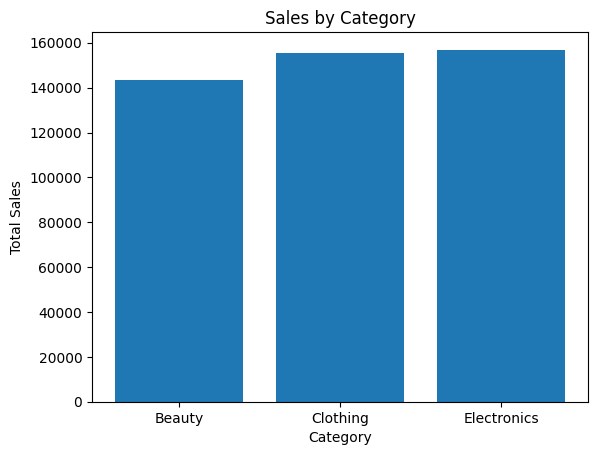

In [9]:
import matplotlib.pyplot as plt

data = pd.read_sql("""
SELECT [Product Category], SUM([Total Amount]) AS total
FROM sales
GROUP BY [Product Category]
""", conn)

plt.bar(data["Product Category"], data["total"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Insight:
The bar chart shows that the Electronics category has the highest sales, followed closely by Clothing, while Beauty has comparatively lower sales.

## Gender-wise Spending Visualization

This plot shows total spending by each gender.

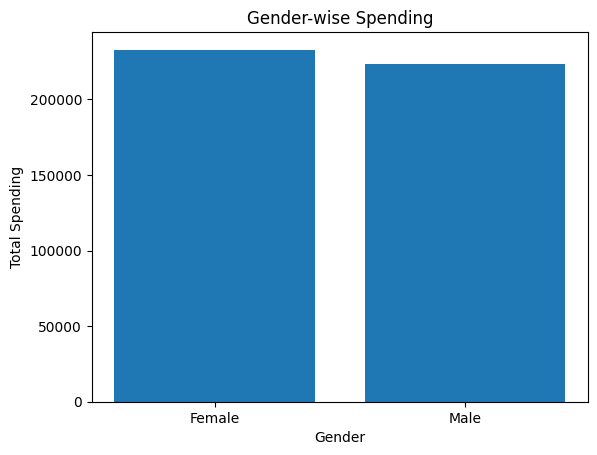

In [10]:
data = pd.read_sql("""
SELECT Gender, SUM([Total Amount]) AS total
FROM sales
GROUP BY Gender
""", conn)

plt.bar(data["Gender"], data["total"])
plt.title("Gender-wise Spending")
plt.xlabel("Gender")
plt.ylabel("Total Spending")
plt.show()

### Insight:
The bar chart shows that female customers have slightly higher total spending compared to male customers, indicating a marginally higher contribution to overall revenue.

## Conclusion

In this project, the retail sales dataset was analyzed using SQLite and SQL queries. Key operations such as aggregation, grouping, filtering, and sorting were performed to extract meaningful insights.

The analysis revealed that:
- Electronics is the highest performing product category.
- Female customers contribute slightly more to total sales.
- High-value transactions are mostly associated with electronics.
- Sales show variation across different months, indicating seasonal trends.

Basic data visualization using bar charts helped in better understanding these patterns.

Overall, the project demonstrates how SQL and Python can be combined for efficient data analysis and visualization.